## 数据：在支付宝、微信平台完成首单、且未复购的用户

- user_id：用户ID

- order_waiting_time：首笔订单发起订单到上车的等待时间
- order_trip_distance：首笔订单行程距离
- order_rate：首笔订单评分
- order_platform：首笔订单打车平台（微信、支付宝）
- register_day：注册天数

- is_send_message：是否发优惠券短信，1为发短信、0为不发短信
- coupon_amount：发放的优惠券金额，0为不发优惠券
- first_order_coupon：首单使用优惠券
- is_click_url：是否点击短信链接
- is_enter_platform：7天内是否进入平台
- Is_repurchase：7天内是否复购

In [1]:
import pandas as pd

df = pd.read_csv('/Users/qianhonglin/Desktop/Data Analyst/Project 2 网约车复购率优化策略 - 钱鸿林/taxi_order_data.csv')
df

,order_trip_distance,order_waiting_time,order_rate,register_day,order_platform,first_order_coupon,coupon_amount,is_click_url,is_enter_platform,is_repurchase,user_id,is_send_message
0,2.6,3.7,5,1,支付宝,10元立减券,0,0,0,0,951090839,0
1,6.1,5.9,4,2,支付宝,10元立减券,7,0,0,0,745349137,1
2,5.9,7.8,4,11,支付宝,5元立减券,4,0,0,0,288698391,1
3,9.2,3.2,5,5,微信,10元立减券,8,0,1,0,795641589,1
4,3.5,3.3,5,1,微信,10元立减券,5,1,0,0,162673720,1
...,...,...,...,...,...,...,...,...,...,...,...,...
795790,4.8,1.8,5,3,微信,5折优惠券,8,0,0,0,204053986,1
795791,5.7,2.3,4,1,微信,10元立减券,4,0,1,0,141806071,1
795792,8.5,1.4,5,5,微信,8元立减券,0,0,0,0,522707438,0
795793,4.7,2.9,5,33,微信,7折优惠券,7,0,0,0,997649283,1



## 第一步：发放优惠券是否提高了支付宝/微信首单用户的7天复购率

### 1. 样本筛选


  * 用户在 **支付宝/微信平台完成首单** 且 有 7 天复购标记

### 2. 分组说明

* **实验组（Treatment）**：收到短信，且优惠券已自动到账  `is_send_message = 1` 且 `coupon_amount > 0`
* **对照组（Control）**：未收到短信，且未发券 `is_send_message = 0` 且 `coupon_amount = 0`

### 3. 复购率计算公式

* 实验组复购率：

  $$
  p^1 = \frac{\text{实验组7天复购人数}}{\text{实验组样本数}}
  $$

* 对照组复购率：

  $$
  p^0 = \frac{\text{对照组7天复购人数}}{\text{对照组样本数}}
  $$

* 提升值：

  $$
  uplift = p^1 - p^0
  $$

### 4. 结果

* 实验组（Treatment）：
  $p^1 = 10.38\%$
* 对照组（Control）：
  $p^0 = 6.47\%$
* **提升值 (uplift)**：
  $p^1 - p^0 = +3.91$ 个百分点 

### 5. 统计检验（Z-test）

* 原假设：$H_0: p^1 = p^0$

* 备择假设：$H_1: p^1 \neq p^0$

* Z 统计量 = **38.60**

* p 值 = **0.0000** （远小于 0.05）

### 6. 结论

拒绝原假设 $H_0$，结果表明： **发放短信+优惠券显著提高了支付宝/微信首单用户的 7 天复购率。**



In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 样本筛选：用户在 支付宝/微信平台完成首单 且 有 7 天复购标记
df_filtered = df[df['order_platform'].isin(['支付宝', '微信'])  & (df['is_repurchase'].notnull())].copy()

treatment = df_filtered[(df_filtered['is_send_message'] == 1) & (df_filtered['coupon_amount'] > 0)]
control = df_filtered[(df_filtered['is_send_message'] == 0) & (df_filtered['coupon_amount'] == 0)]

p1 = treatment['is_repurchase'].mean()
p0 = control['is_repurchase'].mean()
uplift = p1 - p0

print(f"实验组复购率 (p1): {p1*100:.2f}%")
print(f"对照组复购率 (p0): {p0*100:.2f}%")
print(f"提升值 (uplift): {uplift*100:.2f}%")

# Z-test 验证显著性
count = np.array([treatment['is_repurchase'].sum(), control['is_repurchase'].sum()])
nobs = np.array([treatment.shape[0], control.shape[0]])
stat, pval = proportions_ztest(count, nobs) # 默认双侧检验

print(f"Z 统计量: {stat:.2f}")
print(f"P 值: {pval:.4e}")


# 判断显著性
if pval < 0.05:
    print("结论: 差异显著，发放优惠券显著提升了7天复购率。")
else:
    print("结论: 差异不显著，发放优惠券没有显著提升7天复购率。")

实验组复购率 (p1): 10.38%
对照组复购率 (p0): 6.47%
提升值 (uplift): 3.91%
Z 统计量: 38.60
P 值: 0.0000e+00
结论: 差异显著，发放优惠券显著提升了7天复购率。


## 2）识别出哪类用户发优惠券短信无法提高复购率，用于节省短信费用？
    


**目标**：找出发短信+发券不能提升复购率的用户，节省短信费用。

**样本**：

* 支付宝/微信首单用户，首单+1天未复购，且被随机分到实验/对照
* 实验组：发短信+发券 (t=1)
* 对照组：不发短信、不发券 (t=0)
* 结果标签：2–7天内是否复购 (y=1/0)

**特征 X**：首单时可得（注册时长、首单金额/品类、下单时间段、城市等级、渠道、设备等）。⚠️ 不用点击短信、券金额等后验特征。

**方法**：

* 模型：`UpliftTreeClassifier`
* 输出：每个用户 uplift

  $$
  \Delta p = P(y=1|t=1) - P(y=1|t=0)
  $$

**筛选规则**：

* Δp ≤ 0 → **不发短信**
* Δp > 0 → **发短信**

**结果**：输出名单（user\_id, predicted\_uplift），评估 Qini 曲线。


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from causalml.inference.tree import UpliftTreeClassifier
from causalml.metrics.visualize import plot_qini
from causalml.metrics import qini_score

import matplotlib.pyplot as plt


#  1) 样本集合 
df = df[df['order_platform'].isin(['支付宝', '微信'])].copy()

df['y'] = df['is_repurchase'].astype(int)
df['treatment'] = np.where(df['is_send_message'] == 1, 'send_message', 'no_message')

# 2) 特征工程 
num_features = ['register_day', 'order_waiting_time', 'order_trip_distance', 'order_rate']
cat_features = ['order_platform','first_order_coupon']

X = df[num_features + cat_features].copy()
y = df['y'].values
treatment = df['treatment'].values
user_ids = df['user_id'].values

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_mat = preprocessor.fit_transform(X)

# 3) 划分训练/测试集 
X_train, X_test, y_train, y_test, t_train, t_test, uid_train, uid_test = train_test_split(
    X_mat, 
    y, 
    treatment, 
    user_ids, 
    test_size=0.2, 
    random_state=42, 
    stratify=treatment
)

# 4) 训练 uplift tree 
uplift_model = UpliftTreeClassifier(
    control_name='no_message',
    max_depth=5,
    min_samples_leaf=50,
)

uplift_model.fit(X=X_train, treatment=t_train, y=y_train)

#  5) uplift 预测 
proba = uplift_model.predict(X_test)

# proba[:, 0] = P(repurchase=1 | no_message)
# proba[:, 1] = P(repurchase=1 | send_message)


# uplift = P(repurchase = 1 | send_message) - P(repurchase = 1 | no_message)
uplift_vals = proba[:, 1] - proba[:, 0]

result_df = pd.DataFrame({
    'P_no_message': proba[:, 0],     # 用户在“不发短信”组下被预测为复购（order=1）的概率（对照组预测概率）
    'P_send_message':     proba[:, 1],     # 用户在“发短信”组下被预测为复购（order=1）的概率（试验组预测概率）
    'model_uplift':   uplift_vals,     # 模型预测的 uplift 值，表示因干预带来的增量概率
    'treatment':      t_test,          # 测试集中每个样本的实际分组标签
    'actual_outcome': y_test           # 测试集中每个样本的真实结果（is_repurchase，0/1 表示是否复购）
})


# 映射 treatment 为 0/1
result_df['treatment_map'] = df['treatment'].map({'no_message': 0, 'send_message': 1}).astype(int)

print(f"满足 model_uplift <= 0 的用户数：{(result_df['model_uplift'] <= 0).sum()} / {len(result_df)}")



/opt/anaconda3/envs/causalml_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


满足 model_uplift <= 0 的用户数：52 / 159159


<Figure size 3900x1800 with 0 Axes>

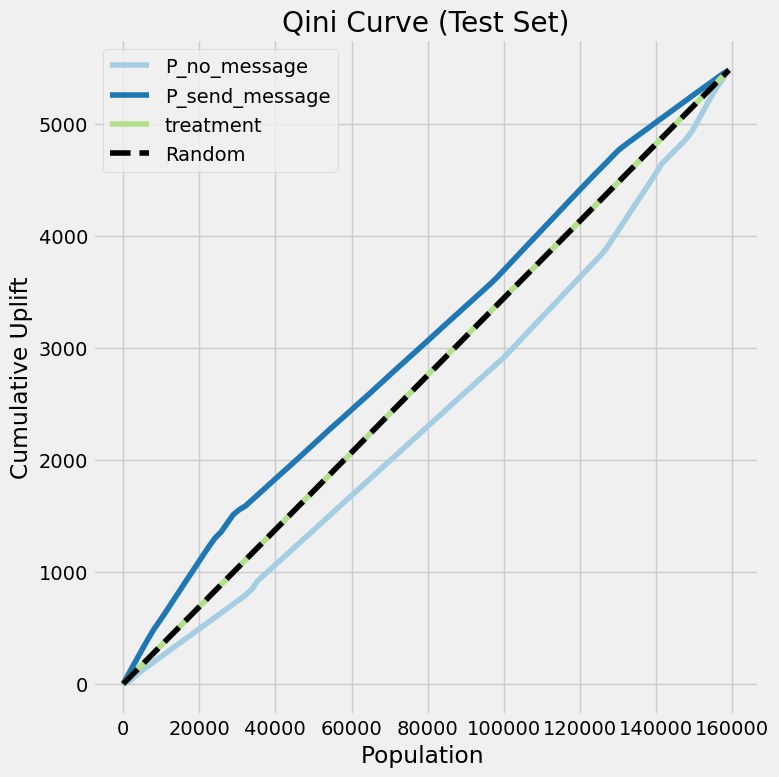

模型的 Qini score: P_no_message     -342.484628
P_send_message    296.167839
treatment           0.537170
dtype: float64


In [4]:
from causalml.metrics.visualize import plot_qini
from causalml.metrics import qini_score
import matplotlib.pyplot as plt

# 画 Qini 曲线
plt.figure(figsize=(13, 6), dpi=300)

plot_qini(
    result_df,                            # DataFrame：包含实际结果、处理分组和模型预测提升值
    outcome_col='actual_outcome',         # str：实际观测结果列名，用于计算累积提升
    treatment_col='treatment_map',        # str：处理分组列名，指示哪些样本接受了处理
    treatment_effect_col='model_uplift',  # str：模型预测的个体提升效果列名
    normalize=False                       # bool：是否对累积提升值进行归一化；False 表示使用原始提升值
)
plt.title("Qini Curve (Test Set)")
plt.xlabel("Population ")
plt.ylabel("Cumulative Uplift")
plt.tight_layout()
plt.show()

# 计算 Qini score
score = qini_score(
    result_df,
    outcome_col='actual_outcome',
    treatment_col='treatment_map',
    treatment_effect_col='model_uplift',
    normalize=False
)

print(f"模型的 Qini score: {score}")

## 2）识别出哪类用户发优惠券短信无法提高复购率，用于节省短信费用？


In [5]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
import warnings
warnings.filterwarnings("ignore")


# 分离数值 & OHE 特征
X_scaled      = preprocessor.transform(df)
n_num         = len(num_features)
X_num_scaled  = X_scaled[:, :n_num]
X_cat_ohe     = X_scaled[:, n_num:]

# 数值部分逆变换到“原始”尺度
# scaler        = preprocessor.named_transformers_['num']
X_num_orig    = preprocessor.named_transformers_['num'].inverse_transform(X_num_scaled)

# 横向拼接：原始数值 + OHE 数值（0/1）
X_rebuilt     = np.hstack([X_num_orig, X_cat_ohe])

# 构造特征名（原数值名 + OHE 名）
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names     = num_features + list(cat_feature_names)

df_repr       = pd.DataFrame(X_rebuilt, columns=feature_names)


# 全数据计算 uplift、生成 mask
proba         = uplift_model.predict(X_scaled)   # 或 .predict_proba
uplift_vals   = proba[:, 1] - proba[:, 0]
mask          = uplift_vals <= 0


result_df = pd.DataFrame({
    'P_no_threshold': proba[:, 0],
    'P_discount':     proba[:, 1],
    'model_uplift':   uplift_vals
})

print(f'满足 model_uplift <= 0 的用户数：' f'{(result_df["model_uplift"] <= 0).sum()} / {len(result_df)}')


满足 model_uplift <= 0 的用户数：254 / 795795


|--- order_trip_distance <= 15.35
|   |--- class: False
|--- order_trip_distance >  15.35
|   |--- first_order_coupon_5元立减券 <= 0.50
|   |   |--- class: False
|   |--- first_order_coupon_5元立减券 >  0.50
|   |   |--- register_day <= 8.50
|   |   |   |--- class: True
|   |   |--- register_day >  8.50
|   |   |   |--- class: False



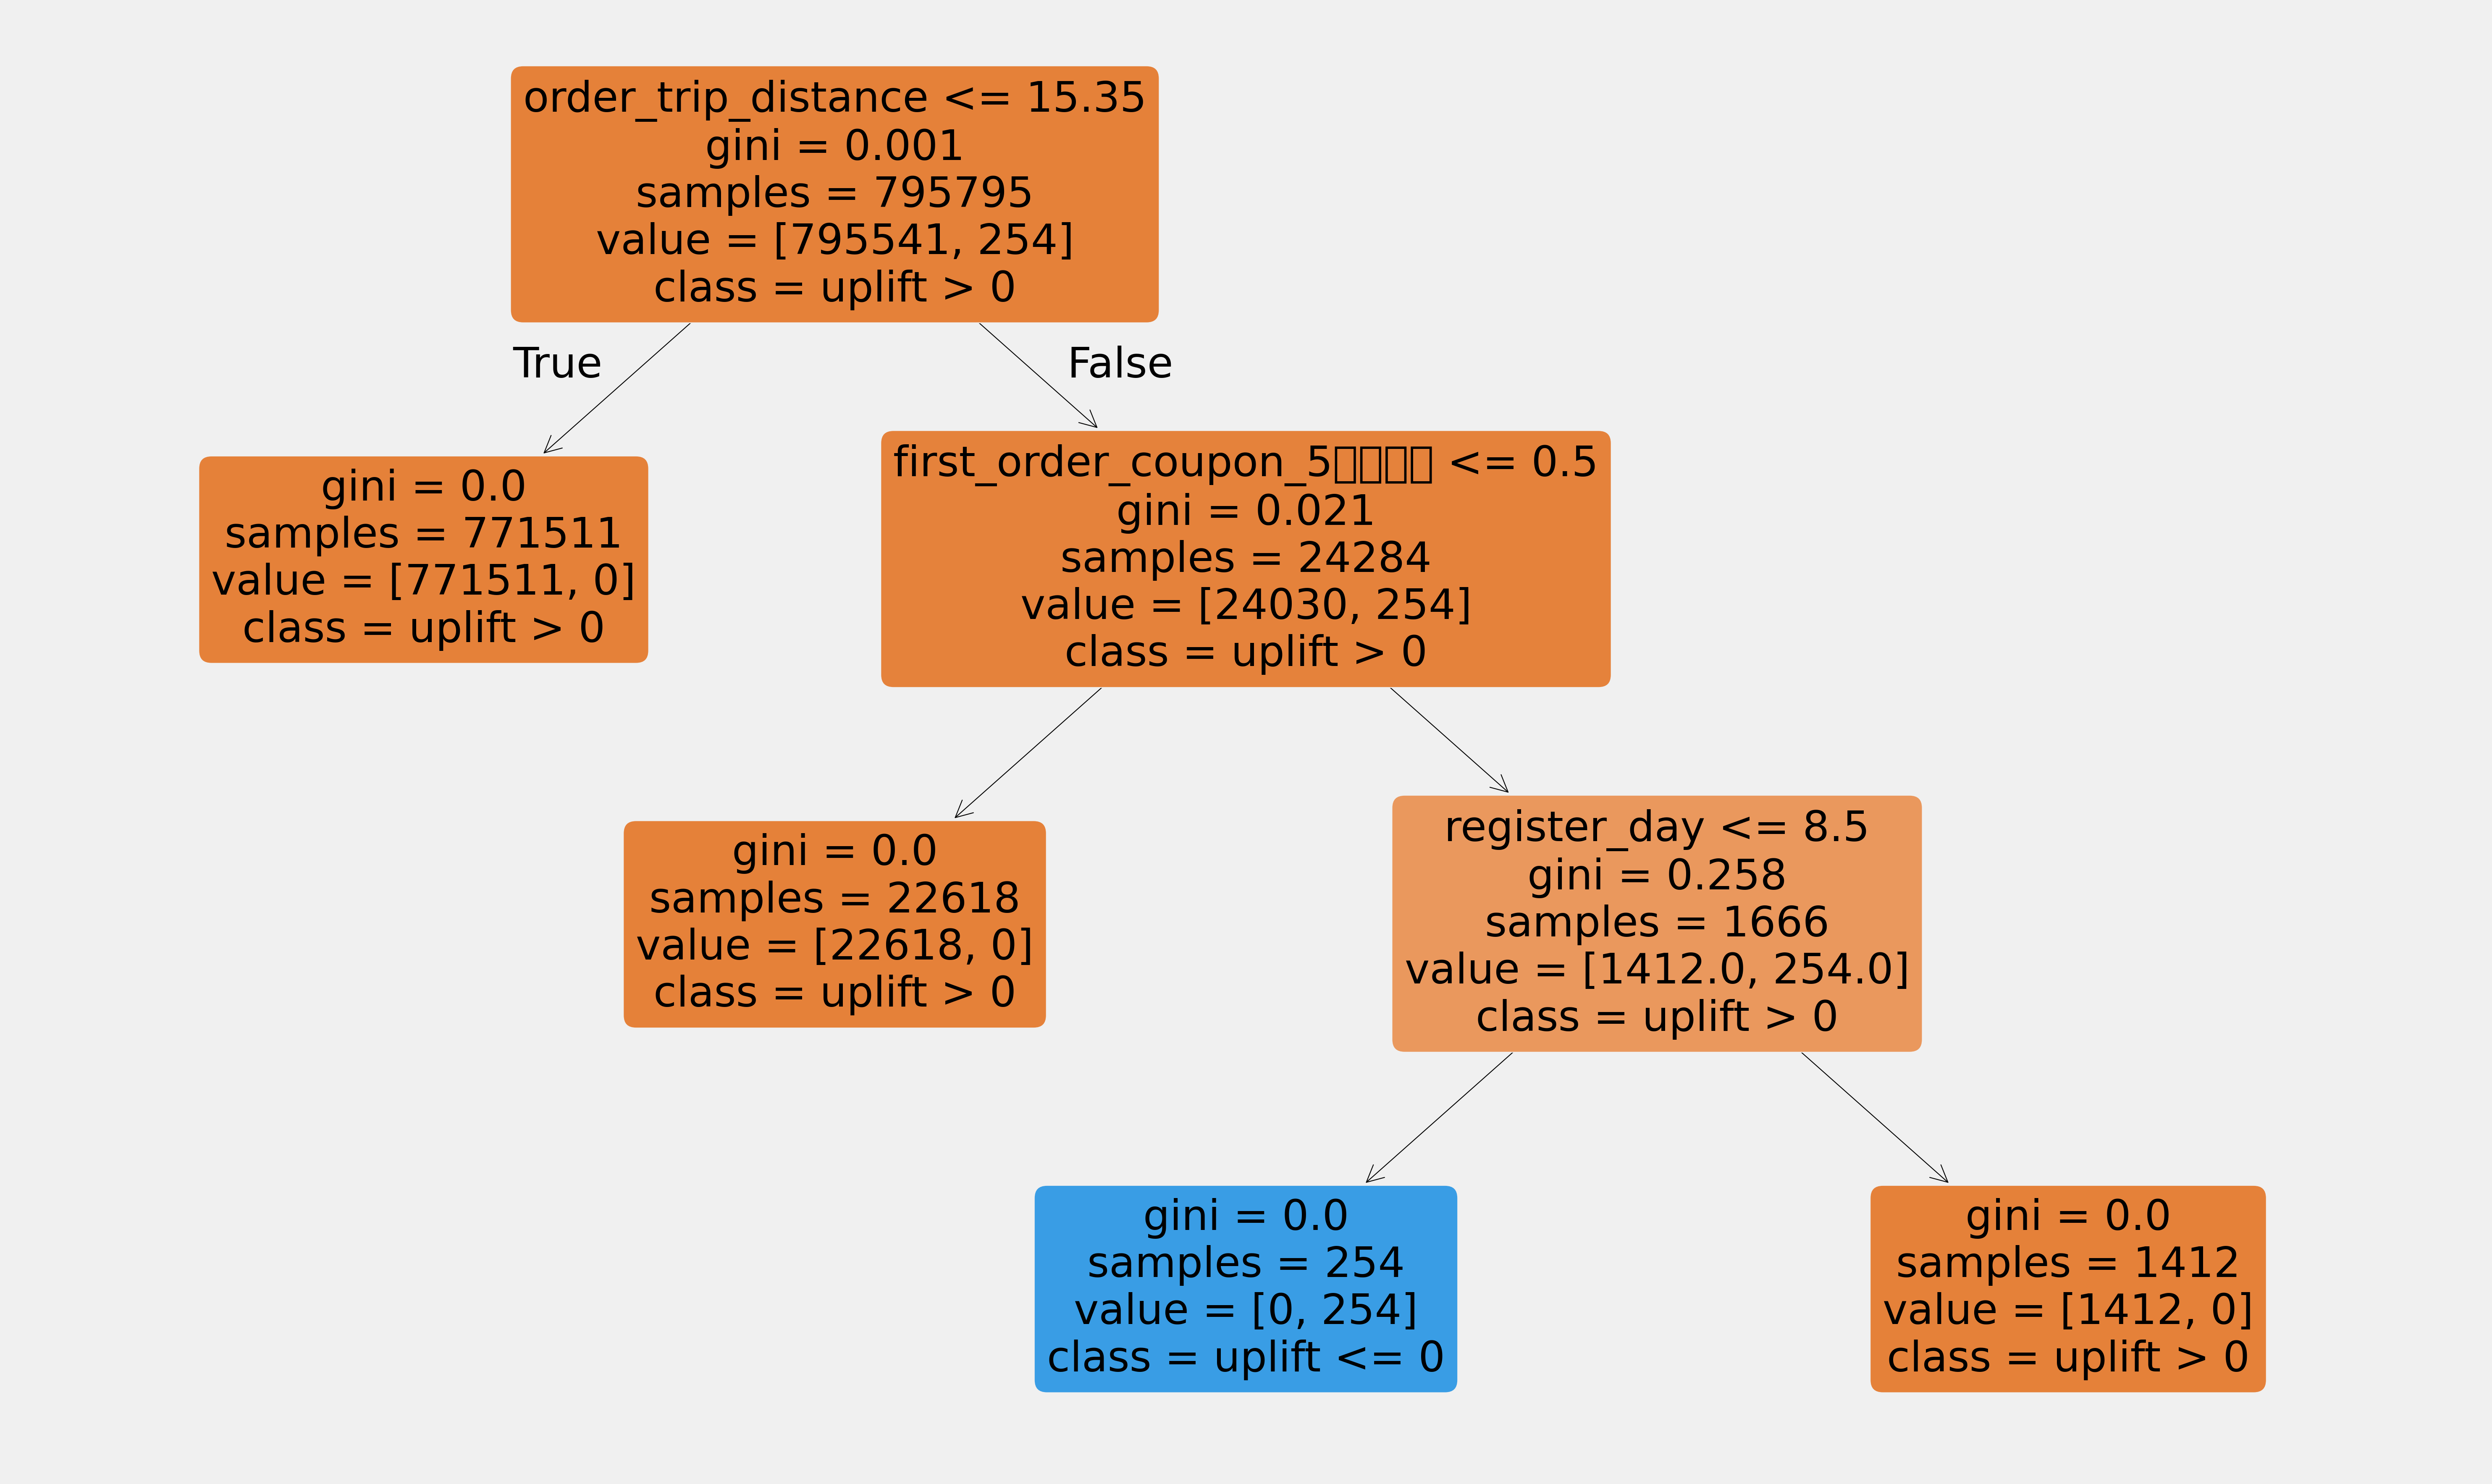

In [6]:
# 在“原始”特征上重训练决策树
rule_tree     = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50)
rule_tree.fit(df_repr, mask)


# mask = (uplift_vals <= 0) → 树学的是 哪些人发短信没用（不值得发）。


print(export_text(rule_tree, feature_names=feature_names))

plt.figure(figsize=(20, 12), dpi=300)
plot_tree(
    rule_tree,
    feature_names=feature_names,
    class_names=['uplift > 0', 'uplift <= 0'], # 顺序严格对应 [0,1]
    filled=True,
    rounded=True
)

plt.tight_layout()
plt.show()

### 总结成业务规则：不值得发短信的人群

### 下单距离 超过 15.35 公里，并且 领取过 5 元首单优惠券，并且 注册天数 在 8 天以内 的用户。


## 3）分析用户在哪个优惠券金额下的复购率最高？


### 1. 特征准备


* 选取用户画像和订单特征作为协变量 `X`。对离散变量做 one-hot 编码（比如平台类型、首单是否有券）。
* T = 用户获得的优惠券金额（离散处理变量）。
* Y = 是否复购（二元结果）。


### 2. 定义因果森林模型


* `model_t`：预测给定用户画像时，平台会发多少金额的券。
* `model_y`：预测在 (T, X) 下，用户复购的概率。
* `CausalForestDML`：通过双重机器学习（DML）校正偏差，估计个体处理效应 (ITE)。


### 3. 个体最优优惠券金额 (个性化推荐)

* 遍历候选优惠券金额（4–10元）。
* 计算 **该用户在金额 t 相比 4 元时复购率提升多少**。
* 找到提升效果最大的金额 → 个体最优优惠券。


###  整体逻辑总结

1. 用因果森林学习优惠券金额对复购率的因果效应。
2. 得到个体最优优惠券金额 (ITE)，实现个性化优惠券分配。



In [7]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from causalml.metrics.visualize import plot_qini
from causalml.metrics import qini_score
from causalml.metrics import auuc_score

from tqdm import tqdm
import numpy as np


# 分析人群需要限制是接收了短信且7天内进入平台的用户，因为只有进入了平台才能看到优惠券金额 ！！！！！！！！！！
df_filtered = df[(df["is_send_message"] == 1) & (df["is_enter_platform"] == 1)]


X = df_filtered[[
    "order_waiting_time",
    "order_trip_distance",
    "order_rate",
    "order_platform",
    "register_day",
    "first_order_coupon"
]]
X = pd.get_dummies(X, columns=["order_platform", "first_order_coupon"], drop_first=True)

T = df_filtered["coupon_amount"].values   # 连续处理：优惠券金额
Y = df_filtered["is_repurchase"].values   # 二分类：是否复购


X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(X, T, Y, test_size=0.2, random_state=42)

est = CausalForestDML(

    # model_t
    # 拟合 T（优惠券金额）和协变量 X 的关系。
    # 相当于回答：“给定用户画像和订单特征，平台可能给他多少金额的券？”
    # 用随机森林回归器来做，因为 T 是连续变量（金额）。

    model_t=RandomForestClassifier( # 第一阶段：拟合 coupon_amount（处理变量 T）的模型
        n_estimators=50,        
        min_samples_leaf=10,   
        random_state=42          
    ),

    # model_y
    # 拟合 Y（是否复购）和 (T, X) 的关系。
    # 回归器预测的是 复购概率（0-1 之间），所以用回归而不是分类。

    model_y=RandomForestClassifier( # 第二阶段：拟合 is_repurchase（结果变量 Y）的模型
        n_estimators=50,        
        min_samples_leaf=10,     
        random_state=42
    ),

    # CausalForestDML 本身的超参数
    n_estimators=100,           
    min_samples_leaf=5,        
    discrete_treatment=True,
    discrete_outcome=True,
    random_state=42              
)


est.fit(Y_train, T_train, X = X_train)

# 针对每个用户，寻找最优优惠券金额
all_effects = {}

# 计算每个金额 vs 4 元的 uplift（批量）
for t in tqdm(range(5, 11)):
    eff = est.effect(X, T0=np.full(len(X), 4), T1=np.full(len(X), t))
    all_effects[t] = eff.ravel()

# est.effect = 因果森林输出，用于「预测 Δ uplift（效应）」。（复购率提升 或 下降了多少）
# 个体处理效应 (ITE) 模型估计的“每个用户拿到更高金额优惠券时复购率的提升效果”。
# 在 econml.CausalForestDML 里，est.effect(X_test) 默认比较的是：处理变量 T 增加一个单位（+1）对结果 Y 的影响。

# 也就是说：baseline = 用户自己在训练数据中的 实际金额
# T1 = baseline + 1
# 所以 te_pred[i] = 如果该用户的优惠券金额比他本来拿到的金额再多 1 元，复购概率会增加多少。

df_uplift = pd.DataFrame(all_effects, index=df_filtered["user_id"])
df_uplift.index.name = "user_id"

# 找到最优金额和最大 uplift
optimal_coupon = df_uplift.idxmax(axis=1)       # 每行最大值的列名（最佳金额）
predicted_uplift = df_uplift.max(axis=1)        # 最大 uplift 值

# 如果所有 uplift <= 0，则选4元
optimal_coupon = optimal_coupon.where(predicted_uplift > 0, 4)


# 最终结果表
df_optimal_vs4 = pd.concat([
    df_filtered[["user_id"]].reset_index(drop=True),
    pd.Series(T, name="actual_coupon"),   # 实际发放金额
    df_uplift.reset_index(drop=True),     # 每个金额的 uplift，一元一列
    pd.Series(optimal_coupon.values, name="optimal_coupon_vs4"),
    pd.Series(predicted_uplift.values, name="predicted_uplift_vs4")
], axis=1)

df_optimal_vs4

100%|██████████| 6/6 [00:06<00:00,  1.12s/it]


,user_id,actual_coupon,5,6,7,8,9,10,optimal_coupon_vs4,predicted_uplift_vs4
0,795641589,8,-0.140928,-0.236254,-0.049155,0.067892,-0.012887,-0.045675,8,0.067892
1,809872094,9,0.096219,-0.027597,-0.054105,0.121015,-0.120428,-0.114435,8,0.121015
2,826052918,5,-0.082745,0.138214,0.085222,0.064695,0.298322,0.078568,9,0.298322
3,231904133,6,0.036501,0.260983,-0.026969,0.017866,-0.029692,0.199894,6,0.260983
4,833002734,5,0.173408,0.048942,0.027179,0.213616,0.354087,0.144420,9,0.354087
...,...,...,...,...,...,...,...,...,...,...
156125,882937665,10,-0.037101,-0.072005,0.006680,0.028330,0.073875,0.024721,9,0.073875
156126,679123886,7,-0.160774,-0.028458,0.158240,0.256087,0.094225,0.368395,10,0.368395
156127,886955733,4,0.177878,0.168273,0.037205,0.105618,0.174261,0.227369,10,0.227369
156128,107749841,6,-0.148884,0.214376,0.190706,0.058533,0.259444,0.311928,10,0.311928


## 4）相比于发最低的4元优惠券，其他金额的优惠券每多 1 元是否能得到一个成本效益比较高的优惠券金额推荐方案？


### 第一步：筛选分析人群


  * 基于“问题 2”的 uplift 决策树，筛选出 **值得发短信的人群**（即短信能显著提升复购率的人）。

  * 在上述人群中，再限定 **接收了短信且 7 天内进入过平台的用户**。理由：只有进入平台的用户才能看到并使用优惠券金额。

* **最终分析样本**

  * `user_id` ∈ {应发短信人群 ∩ is\_send\_message=1 ∩ is\_enter\_platform=1}



### 第二步：针对每个用户的成本效益 ROI 分析

#### 分析目标：在进入平台的“应发短信人群”中，对 **每个用户** 计算不同优惠券金额（5–10 元，相比 4 元基准）的 **单位成本效益 ROI**，从而得到个性化推荐的最优金额。

#### 计算方法

1. **复购率提升 (uplift)**
   对于用户 *i*，优惠券金额 *t* (t ∈ {5,…,10}) 相比于 4 元的 uplift：

   $$
   \Delta Y_{i,t} = \hat{Y}(X_i, T=t) - \hat{Y}(X_i, T=4)
   $$

   其中 $\hat{Y}(X_i, T)$ 表示模型预测的复购概率。

2. **单位成本 ROI**

   $$
   ROI_{i,t} = \frac{\Delta Y_{i,t}}{t-4}
   $$

   表示每多花 1 元券成本，为用户 *i* 带来的复购率提升。

3. **最优金额选择**

   * 对每个用户，找到使 $ROI_{i,t}$ 最大的金额 $t$：
   * 若所有 $\Delta Y_{i,t} \le 0$，则说明该用户相比 4 元没有额外提升 → 推荐维持 4 元。



### 第三步：推荐方案

* 在“筛选的人群”中，比较 5–10 元的 ROI：

  * 若 **5 元 ROI 最高** → 则推荐 5 元作为主推券额；
  * 若 **6 元或 7 元 ROI 更优** → 则在预算允许时可作为替代方案；
  * 若 **所有 ΔY\_t ≤ 0** → 表示该人群相比 4 元没有额外提升，应维持 4 元。



In [8]:
import numpy as np
import pandas as pd

# 筛选进入平台 & 值得发短信的人 
df_target = df.copy()
df_target["uplift"] = uplift_vals   # 这是短信uplift模型的预测结果
df_target = df_target[
    (df_target["is_send_message"] == 1) &
    (df_target["is_enter_platform"] == 1) &
    (df_target["uplift"] > 0)   # 值得发短信的人
]

X_target = X.loc[df_target.index]   # 特征子集

# 计算每个用户在不同金额下 uplift
all_effects = {}
for t in range(5, 11):
    eff = est.effect(
        X_target,
        T0=np.full(len(X_target), 4),   # baseline: 4元
        T1=np.full(len(X_target), t)    # 处理: t元
    )
    all_effects[t] = eff.ravel()

df_uplift_user = pd.DataFrame(all_effects, index=df_target["user_id"])
df_uplift_user.index.name = "user_id"

# 计算每个用户的 ROI
df_roi_user = df_uplift_user.copy()
for t in range(5, 11):
    df_roi_user[t] = df_roi_user[t] / (t - 4)   # 单位成本ROI

# 找到每个用户ROI最大值 和 对应的coupon value
best_coupon_by_roi = df_roi_user.idxmax(axis=1)
best_roi_value = df_roi_user.max(axis=1)

# 如果所有 uplift <= 0，则回退到4元（ROI=0）
mask_all_negative = (df_uplift_user.max(axis=1) <= 0)
best_coupon_by_roi[mask_all_negative] = 4
best_roi_value[mask_all_negative] = 0

df_optimal_user = pd.concat([
    df_target[["user_id"]].reset_index(drop=True),
    pd.Series(df_target["coupon_amount"].values, name="actual_coupon"),
    df_roi_user.reset_index(drop=True),   # 每个金额的 ROI
    pd.Series(best_coupon_by_roi.values, name="best_coupon_by_roi"),
    pd.Series(best_roi_value.values, name="best_roi_value")
], axis=1)

df_optimal_user

,user_id,actual_coupon,5,6,7,8,9,10,best_coupon_by_roi,best_roi_value
0,795641589,8,-0.140928,-0.118127,-0.016385,0.016973,-0.002577,-0.007613,8,0.016973
1,809872094,9,0.096219,-0.013799,-0.018035,0.030254,-0.024086,-0.019072,5,0.096219
2,826052918,5,-0.082745,0.069107,0.028407,0.016174,0.059664,0.013095,6,0.069107
3,231904133,6,0.036501,0.130491,-0.008990,0.004467,-0.005938,0.033316,6,0.130491
4,833002734,5,0.173408,0.024471,0.009060,0.053404,0.070817,0.024070,5,0.173408
...,...,...,...,...,...,...,...,...,...,...
156080,882937665,10,-0.037101,-0.036002,0.002227,0.007082,0.014775,0.004120,9,0.014775
156081,679123886,7,-0.160774,-0.014229,0.052747,0.064022,0.018845,0.061399,8,0.064022
156082,886955733,4,0.177878,0.084136,0.012402,0.026405,0.034852,0.037895,5,0.177878
156083,107749841,6,-0.148884,0.107188,0.063569,0.014633,0.051889,0.051988,6,0.107188
